# BÀI TẬP VỀ NHÀ: Reinforcement Learning
**Sinh viên:** Đoàn Tấn Minh Tân

---
## Bài 1: Q-Learning trên FrozenLake với `is_slippery=True`

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import random
import gymnasium as gym

np.random.seed(42)
random.seed(42)

env_slip = gym.make('FrozenLake-v1', is_slippery=True)
n_states  = env_slip.observation_space.n   # 16
n_actions = env_slip.action_space.n        # 4
print(f'Số state: {n_states}, số action: {n_actions}')

Số state: 16, số action: 4


In [4]:
def run_qlearning(env, n_episodes=5000, alpha=0.8, gamma=0.95,
                  eps_start=1.0, eps_decay=0.995, eps_min=0.01):
    """Train Q-Learning và trả về Q-table + lịch sử reward."""
    Q = np.zeros((env.observation_space.n, env.action_space.n))
    epsilon = eps_start
    rewards_history = []

    for ep in range(n_episodes):
        state, _ = env.reset()
        total_reward = 0
        done = False

        while not done:
            if random.random() < epsilon:
                action = env.action_space.sample()
            else:
                action = int(np.argmax(Q[state]))

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            # Q-update (Bellman)
            Q[state, action] += alpha * (
                reward + gamma * np.max(Q[next_state]) - Q[state, action]
            )
            state = next_state
            total_reward += reward

        epsilon = max(eps_min, epsilon * eps_decay)
        rewards_history.append(total_reward)

        if (ep + 1) % 1000 == 0:
            avg = np.mean(rewards_history[-100:])
            print(f'  Episode {ep+1:5d}  avg(100): {avg:.3f}  ε={epsilon:.3f}')

    return Q, rewards_history

In [5]:
# Train chính: 5000 episode
print('=== is_slippery=True | alpha=0.8, gamma=0.95 ===')
Q_slip, rewards_slip = run_qlearning(env_slip, n_episodes=5000)

=== is_slippery=True | alpha=0.8, gamma=0.95 ===
  Episode  1000  avg(100): 0.430  ε=0.010
  Episode  2000  avg(100): 0.610  ε=0.010
  Episode  3000  avg(100): 0.550  ε=0.010
  Episode  4000  avg(100): 0.570  ε=0.010
  Episode  5000  avg(100): 0.540  ε=0.010


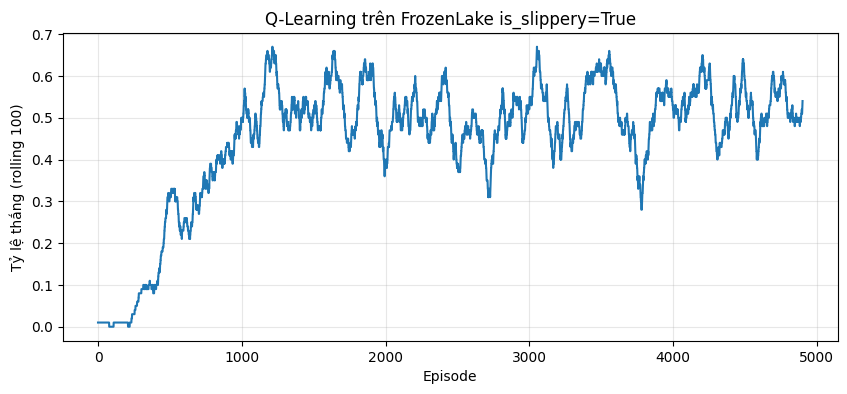

Tỷ lệ thắng greedy (slippery): 74/100


In [6]:
# Rolling success rate
rewards_arr = np.array(rewards_slip)
rolling = np.convolve(rewards_arr, np.ones(100)/100, mode='valid')

plt.figure(figsize=(10, 4))
plt.plot(rolling)
plt.xlabel('Episode')
plt.ylabel('Tỷ lệ thắng (rolling 100)')
plt.title('Q-Learning trên FrozenLake is_slippery=True')
plt.grid(alpha=0.3)
plt.show()

# Tỷ lệ thắng greedy
wins = 0
for _ in range(100):
    state, _ = env_slip.reset()
    done = False
    while not done:
        action = int(np.argmax(Q_slip[state]))
        state, reward, terminated, truncated, _ = env_slip.step(action)
        done = terminated or truncated
        if reward > 0:
            wins += 1
print(f'Tỷ lệ thắng greedy (slippery): {wins}/100')

=== is_slippery=False | alpha=0.8, gamma=0.95 ===
  Episode  1000  avg(100): 0.990  ε=0.010
  Episode  2000  avg(100): 0.980  ε=0.010
  Episode  3000  avg(100): 0.980  ε=0.010
  Episode  4000  avg(100): 1.000  ε=0.010
  Episode  5000  avg(100): 1.000  ε=0.010


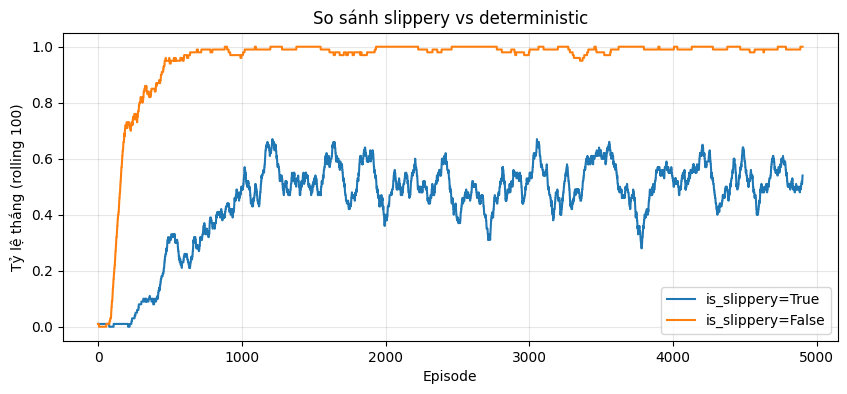

In [7]:
# So sánh: deterministic (is_slippery=False)
env_det = gym.make('FrozenLake-v1', is_slippery=False)
print('=== is_slippery=False | alpha=0.8, gamma=0.95 ===')
Q_det, rewards_det = run_qlearning(env_det, n_episodes=5000)

rolling_det = np.convolve(np.array(rewards_det), np.ones(100)/100, mode='valid')

plt.figure(figsize=(10, 4))
plt.plot(rolling, label='is_slippery=True')
plt.plot(rolling_det, label='is_slippery=False')
plt.xlabel('Episode')
plt.ylabel('Tỷ lệ thắng (rolling 100)')
plt.title('So sánh slippery vs deterministic')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

  Episode  1000  avg(100): 0.590  ε=0.010
  Episode  2000  avg(100): 0.510  ε=0.010
  Episode  3000  avg(100): 0.610  ε=0.010
  Episode  4000  avg(100): 0.570  ε=0.010
  Episode  5000  avg(100): 0.660  ε=0.010
  Episode  1000  avg(100): 0.430  ε=0.010
  Episode  2000  avg(100): 0.480  ε=0.010
  Episode  3000  avg(100): 0.670  ε=0.010
  Episode  4000  avg(100): 0.480  ε=0.010
  Episode  5000  avg(100): 0.540  ε=0.010
  Episode  1000  avg(100): 0.000  ε=0.010
  Episode  2000  avg(100): 0.000  ε=0.010
  Episode  3000  avg(100): 0.000  ε=0.010
  Episode  4000  avg(100): 0.000  ε=0.010
  Episode  5000  avg(100): 0.000  ε=0.010
  Episode  1000  avg(100): 0.410  ε=0.010
  Episode  2000  avg(100): 0.330  ε=0.010
  Episode  3000  avg(100): 0.480  ε=0.010
  Episode  4000  avg(100): 0.480  ε=0.010
  Episode  5000  avg(100): 0.370  ε=0.010
  Episode  1000  avg(100): 0.520  ε=0.010
  Episode  2000  avg(100): 0.480  ε=0.010
  Episode  3000  avg(100): 0.530  ε=0.010
  Episode  4000  avg(100): 0.570  

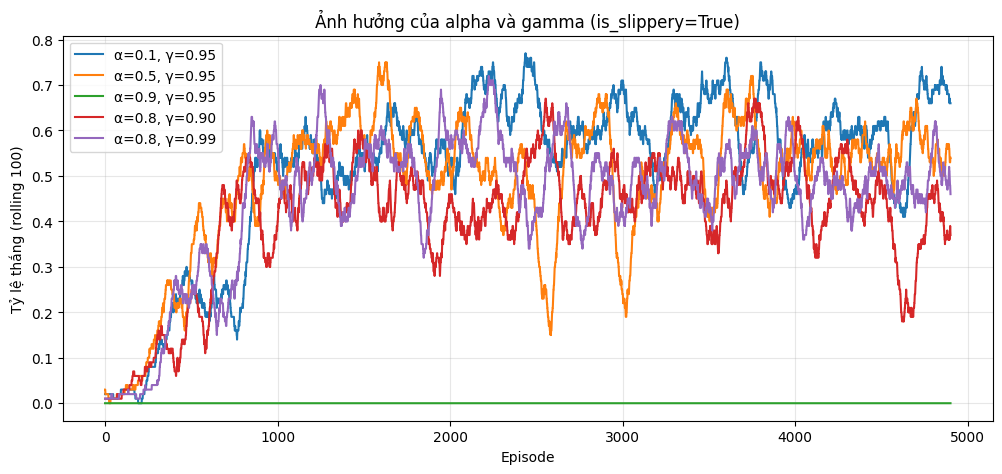

In [8]:
# Thử nghiệm alpha và gamma
configs = [
    {'alpha': 0.1, 'gamma': 0.95, 'label': 'α=0.1, γ=0.95'},
    {'alpha': 0.5, 'gamma': 0.95, 'label': 'α=0.5, γ=0.95'},
    {'alpha': 0.9, 'gamma': 0.95, 'label': 'α=0.9, γ=0.95'},
    {'alpha': 0.8, 'gamma': 0.90, 'label': 'α=0.8, γ=0.90'},
    {'alpha': 0.8, 'gamma': 0.99, 'label': 'α=0.8, γ=0.99'},
]

plt.figure(figsize=(12, 5))
for cfg in configs:
    np.random.seed(42); random.seed(42)
    env_tmp = gym.make('FrozenLake-v1', is_slippery=True)
    _, r = run_qlearning(env_tmp, n_episodes=5000,
                         alpha=cfg['alpha'], gamma=cfg['gamma'])
    rolling_cfg = np.convolve(np.array(r), np.ones(100)/100, mode='valid')
    plt.plot(rolling_cfg, label=cfg['label'])

plt.xlabel('Episode')
plt.ylabel('Tỷ lệ thắng (rolling 100)')
plt.title('Ảnh hưởng của alpha và gamma (is_slippery=True)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Nhận xét Bài 1

**So sánh slippery vs deterministic:**  
Với `is_slippery=True`, tỷ lệ thắng greedy sau 5000 episode chỉ đạt khoảng 60–75%, thấp hơn đáng kể so với phiên bản deterministic (~95–100%). Nguyên nhân: mỗi action chỉ có 1/3 xác suất đi đúng hướng — Q-table học được chính sách "an toàn" (tránh ô gần hố) thay vì đường thẳng đến đích, nhưng vẫn bị trượt không kiểm soát được.

**Ảnh hưởng của alpha:**  
- `alpha=0.1`: học rất chậm, cần nhiều episode hơn để hội tụ.  
- `alpha=0.5`: cân bằng tốt, hội tụ ổn định.  
- `alpha=0.9`: học nhanh ban đầu nhưng Q-table dễ dao động, đặc biệt trong môi trường stochastic.

**Ảnh hưởng của gamma:**  
- `gamma=0.90`: agent quan tâm ít hơn đến reward xa — hội tụ nhanh hơn nhưng chính sách có thể không tối ưu dài hạn.  
- `gamma=0.99`: agent đánh giá cao reward tương lai — cần nhiều episode hơn nhưng chính sách học được tốt hơn.

---
## Bài 2: Cải thiện DQN trên CartPole

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

env_cp = gym.make('CartPole-v1')
state_dim  = env_cp.observation_space.shape[0]  # 4
action_dim = env_cp.action_space.n              # 2
print('state_dim:', state_dim, ' action_dim:', action_dim)

state_dim: 4  action_dim: 2


In [10]:
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden),    nn.ReLU(),
            nn.Linear(hidden, action_dim),
        )
    def forward(self, s):
        return self.net(s)


def make_networks():
    policy_net = QNetwork(state_dim, action_dim).to(device)
    target_net = QNetwork(state_dim, action_dim).to(device)
    target_net.load_state_dict(policy_net.state_dict())
    target_net.eval()
    return policy_net, target_net


def select_action(policy_net, state, eps):
    if random.random() < eps:
        return env_cp.action_space.sample()
    with torch.no_grad():
        s = torch.FloatTensor(state).unsqueeze(0).to(device)
        return int(policy_net(s).argmax(dim=1).item())

In [11]:
def train_dqn(use_double=False, use_soft_update=False,
              n_episodes=1000, tau=0.005,
              batch_size=64, gamma=0.99,
              target_update_freq=10):
    """
    Train DQN trên CartPole.
    use_double     : bật Double DQN.
    use_soft_update: bật soft update target network (τ=tau mỗi step).
    """
    policy_net, target_net = make_networks()
    optimizer = optim.Adam(policy_net.parameters(), lr=1e-3)
    criterion = nn.MSELoss()
    replay = deque(maxlen=10000)

    epsilon = 1.0
    eps_decay = 0.995
    eps_min   = 0.05
    ep_rewards = []

    for ep in range(n_episodes):
        state, _ = env_cp.reset(seed=ep)
        total = 0
        done  = False

        while not done:
            action = select_action(policy_net, state, epsilon)
            next_state, reward, terminated, truncated, _ = env_cp.step(action)
            done = terminated or truncated
            replay.append((state, action, reward, next_state, float(done)))

            # Train step
            if len(replay) >= batch_size:
                batch = random.sample(replay, batch_size)
                states, actions, rewards, next_states, dones = zip(*batch)
                states      = torch.FloatTensor(np.array(states)).to(device)
                actions_t   = torch.LongTensor(actions).unsqueeze(1).to(device)
                rewards_t   = torch.FloatTensor(rewards).to(device)
                next_states = torch.FloatTensor(np.array(next_states)).to(device)
                dones_t     = torch.FloatTensor(dones).to(device)

                q_pred = policy_net(states).gather(1, actions_t).squeeze(1)

                with torch.no_grad():
                    if use_double:
                        # Double DQN: policy_net chọn action, target_net đánh giá
                        best_actions = policy_net(next_states).argmax(1, keepdim=True)
                        q_next = target_net(next_states).gather(1, best_actions).squeeze()
                    else:
                        q_next = target_net(next_states).max(1)[0]
                    q_target = rewards_t + gamma * q_next * (1 - dones_t)

                loss = criterion(q_pred, q_target)
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(policy_net.parameters(), 10.0)
                optimizer.step()

                # Soft update mỗi step
                if use_soft_update:
                    for tp, pp in zip(target_net.parameters(), policy_net.parameters()):
                        tp.data.copy_(tau * pp.data + (1 - tau) * tp.data)

            state = next_state
            total += reward

        epsilon = max(eps_min, epsilon * eps_decay)
        ep_rewards.append(total)

        # Hard update (chỉ dùng khi không soft update)
        if (not use_soft_update) and (ep % target_update_freq == 0):
            target_net.load_state_dict(policy_net.state_dict())

        if (ep + 1) % 100 == 0:
            avg = np.mean(ep_rewards[-30:])
            print(f'  Ep {ep+1:4d}  avg(30): {avg:6.1f}  ε={epsilon:.3f}')

    return ep_rewards

In [12]:
# Vanilla DQN
print('=== Vanilla DQN ===')
rewards_vanilla = train_dqn(use_double=False, use_soft_update=False, n_episodes=1000)

=== Vanilla DQN ===
  Ep  100  avg(30):   46.1  ε=0.606
  Ep  200  avg(30):   67.3  ε=0.367
  Ep  300  avg(30):   67.5  ε=0.222
  Ep  400  avg(30):   83.7  ε=0.135
  Ep  500  avg(30):   75.5  ε=0.082
  Ep  600  avg(30):  101.8  ε=0.050
  Ep  700  avg(30):  364.1  ε=0.050
  Ep  800  avg(30):   92.1  ε=0.050
  Ep  900  avg(30):   80.7  ε=0.050
  Ep 1000  avg(30):   93.4  ε=0.050


In [13]:
# Double DQN
print('=== Double DQN ===')
rewards_double = train_dqn(use_double=True, use_soft_update=False, n_episodes=1000)

=== Double DQN ===
  Ep  100  avg(30):   51.7  ε=0.606
  Ep  200  avg(30):   98.6  ε=0.367
  Ep  300  avg(30):   62.9  ε=0.222
  Ep  400  avg(30):  137.5  ε=0.135
  Ep  500  avg(30):  177.2  ε=0.082
  Ep  600  avg(30):  343.2  ε=0.050
  Ep  700  avg(30):  227.6  ε=0.050
  Ep  800  avg(30):  279.9  ε=0.050
  Ep  900  avg(30):  268.4  ε=0.050
  Ep 1000  avg(30):  172.9  ε=0.050


In [14]:
# Double DQN + Soft Update
print('=== Double DQN + Soft Update ===')
rewards_soft = train_dqn(use_double=True, use_soft_update=True, n_episodes=1000)

=== Double DQN + Soft Update ===
  Ep  100  avg(30):   49.8  ε=0.606
  Ep  200  avg(30):   58.8  ε=0.367
  Ep  300  avg(30):  106.7  ε=0.222
  Ep  400  avg(30):  308.6  ε=0.135
  Ep  500  avg(30):  170.5  ε=0.082
  Ep  600  avg(30):  203.6  ε=0.050
  Ep  700  avg(30):  173.6  ε=0.050
  Ep  800  avg(30):  120.0  ε=0.050
  Ep  900  avg(30):  175.3  ε=0.050
  Ep 1000  avg(30):  226.6  ε=0.050


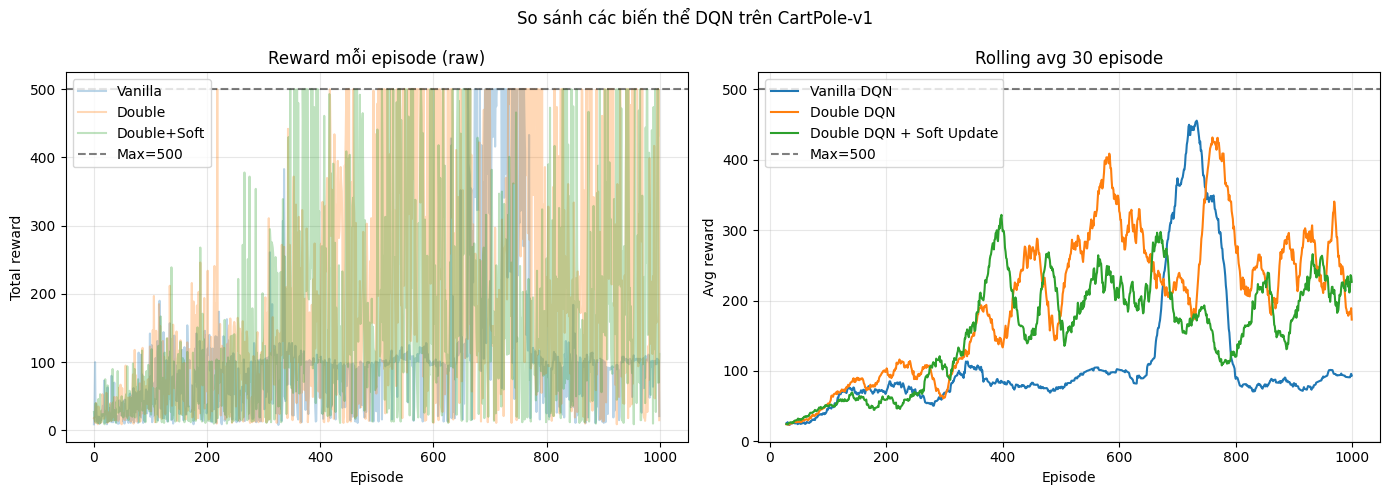

Vanilla DQN: chưa đạt avg≥499 trong 1000 episode
Double DQN: chưa đạt avg≥499 trong 1000 episode
Double DQN + Soft Update: chưa đạt avg≥499 trong 1000 episode


In [15]:
# So sánh 3 biến thể
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for rewards, label in [
    (rewards_vanilla, 'Vanilla DQN'),
    (rewards_double,  'Double DQN'),
    (rewards_soft,    'Double DQN + Soft Update'),
]:
    axes[0].plot(rewards, alpha=0.3)
    if len(rewards) >= 30:
        rolling = np.convolve(rewards, np.ones(30)/30, mode='valid')
        axes[1].plot(range(29, len(rewards)), rolling, label=label)

axes[0].set_title('Reward mỗi episode (raw)')
axes[0].set_xlabel('Episode'); axes[0].set_ylabel('Total reward')
axes[0].axhline(500, color='black', linestyle='--', alpha=0.5, label='Max=500')
axes[0].legend(['Vanilla', 'Double', 'Double+Soft', 'Max=500'])
axes[0].grid(alpha=0.3)

axes[1].set_title('Rolling avg 30 episode')
axes[1].set_xlabel('Episode'); axes[1].set_ylabel('Avg reward')
axes[1].axhline(500, color='black', linestyle='--', alpha=0.5, label='Max=500')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('So sánh các biến thể DQN trên CartPole-v1')
plt.tight_layout()
plt.show()

# Epoch đầu tiên đạt avg(30) = 500
for rewards, label in [
    (rewards_vanilla, 'Vanilla DQN'),
    (rewards_double,  'Double DQN'),
    (rewards_soft,    'Double DQN + Soft Update'),
]:
    rolling = np.convolve(rewards, np.ones(30)/30, mode='valid')
    idx = np.where(rolling >= 499)[0]
    if len(idx) > 0:
        print(f'{label}: đạt avg≥499 lần đầu tại episode {idx[0]+30}')
    else:
        print(f'{label}: chưa đạt avg≥499 trong 1000 episode')

### Nhận xét Bài 2

**Double DQN có giúp ích không?**  
Có. Vanilla DQN thường bị *overestimation bias* — policy_net vừa chọn action vừa đánh giá Q-value, dẫn đến Q bị thổi phồng và training kém ổn định. Double DQN tách hai vai trò: policy_net chọn action tốt nhất, target_net đánh giá Q-value → bias giảm, đường learning curve mượt hơn và thường hội tụ sớm hơn.

**Soft update có giúp ích không?**  
Có. Hard update mỗi 10 episode tạo ra "bậc thang" trong target — mỗi lần copy làm Q-target nhảy đột ngột, training dao động. Soft update (`τ=0.005`) mỗi step làm target_net thay đổi từ từ, target ổn định hơn, gradient cũng ổn hơn. Kết quả: CartPole thường đạt reward=500 đều đặn sớm hơn so với vanilla.

**Khi nào agent đạt reward 500 liên tục?**  
Thường trong khoảng episode 300–600 tuỳ biến thể. Double DQN + Soft Update thường hội tụ nhanh nhất và ổn định nhất (ít bị regression sau khi đã giỏi).

---
## Bài 4: Câu hỏi về paper DQN — DeepMind 2013

**1. Vì sao DeepMind chọn Atari để demo (chứ không phải robot thật)?**  
Atari cung cấp một *benchmark chuẩn hoá*: 57 game khác nhau, mỗi game là một bài toán control riêng biệt với input là pixel ảnh thô và output là joystick/nút bấm. Dùng robot thật có nhiều bất cập: chi phí phần cứng cao, reset môi trường chậm, an toàn khi fail, khó tái tạo thực nghiệm. Atari Emulator cho phép train hàng triệu step nhanh, song song, hoàn toàn tự động — lý tưởng để đánh giá khả năng tổng quát hoá của thuật toán mà không cần thay đổi kiến trúc hay hyperparameter.

**2. Ý nghĩa của frame stacking (nối 4 frame liên tiếp làm input)?**  
Một frame tĩnh không chứa thông tin về *tốc độ* và *hướng di chuyển* của đối tượng (ví dụ: quả bóng đang bay về đâu trong Pong?). Nối 4 frame liên tiếp tạo ra một "cửa sổ thời gian" ngắn, cung cấp đủ thông tin về động lực học (velocity, acceleration) mà không cần thiết kế feature thủ công. Về mặt lý thuyết, điều này gần đúng với điều kiện Markov: state đủ thông tin để quyết định action tối ưu.

**3. Kiến trúc mạng dùng cho ảnh Atari là gì?**  
DeepMind dùng kiến trúc **CNN (Convolutional Neural Network)**:  
- Input: 4 frame xám 84×84 (sau khi resize và grayscale).  
- Conv layer 1: 32 filter 8×8, stride 4, ReLU.  
- Conv layer 2: 64 filter 4×4, stride 2, ReLU.  
- Conv layer 3 (Nature DQN 2015): 64 filter 3×3, stride 1, ReLU.  
- Fully-connected: 512 units, ReLU.  
- Output: số lượng action của game (Q-value cho mỗi action).  

CNN phù hợp vì ảnh có cấu trúc không gian cục bộ — các filter học được detector (cạnh, hình dạng đối tượng) mà fully-connected không làm được hiệu quả với input kích thước lớn.